In [ ]:
# 1) Installations
!pip -q install MDAnalysis MDAnalysisTests numpy pandas matplotlib statsmodels scikit-learn scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.9/108.9 kB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 MB 36.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 90.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 105.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.3/529.3 kB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 5.3 MB/s eta 0:00:00


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import MDAnalysis as mda
from MDAnalysis.analysis import align
from sklearn.decomposition import PCA
from statsmodels.tsa.api import VAR
from statsmodels.stats.multitest import multipletests
from scipy.stats import sem

# --- ENSEMBLE CONFIGURATION ---
REPLICAS = [
    {
        "name": "Rep1",
        "top": "/content/drive/MyDrive/PATH/NAME.prmtop",
        "traj": "/content/drive/MyDrive/PATH/NAME.dcd",
        "outdir": "/content/drive/MyDrive/PATH/Rep1/"
    },
    {
        "name": "Rep2",
        "top": "/content/drive/MyDrive/PATH/NAME.prmtop",
        "traj": "/content/drive/MyDrive/PATH/NAME.dcd",
        "outdir": "/content/drive/MyDrive/PATH/Rep2/"
    },
    {
        "name": "Rep3",
        "top": "/content/drive/MyDrive/PATH/NAME.prmtop",
        "traj": "/content/drive/MyDrive/PATH/NAME.dcd",
        "outdir": "/content/drive/MyDrive/PATH/Rep3/"
    }
]

# Shared Global Parameters
MAIN_OUTDIR = "/content/drive/MyDrive/PATH/ENSEMBLE_RESULTS/"

# Define your "Cause" Protein regions
REGIONS = {
    "n-terminal": "resid X1:Y1 and name CA",
    "c-terminal": "resid X2:Y2 and name CA"
}

# Name your "Target" Features
DNA_TARGETS = ['dna_kb_rmsd', 'dna_minor', 'dna_major']
WINDOW_NS, STEP_NS = 1000, 100
dt_saved_ns, stride = 1.0, 1

os.makedirs(MAIN_OUTDIR, exist_ok=True)
all_rep_summaries = [] # Global list to store final stats for the ensemble

In [ ]:
# Define your "Target" Features

def internal_kabsch_rmsd(universe, selection):
    ag = universe.select_atoms(selection)
    ref_pos = ag.positions.copy()
    ref_pos -= ref_pos.mean(axis=0)
    rmsd_vals = []
    for ts in universe.trajectory:
        curr_pos = ag.positions.copy()
        curr_pos -= curr_pos.mean(axis=0)
        _, rmsd = mda.analysis.align.rotation_matrix(curr_pos, ref_pos)
        rmsd_vals.append(rmsd)
    return np.array(rmsd_vals)

def compute_groove_widths(universe, s1_range, s2_range):
    s1, s2 = universe.select_atoms(f"resid {s1_range} and name P"), universe.select_atoms(f"resid {s2_range} and name P")
    minor, major = [], []
    for ts in universe.trajectory:
        p1, p2 = s1.positions, s2.positions[::-1]
        minor.append(np.mean([np.linalg.norm(p1[j]-p2[j+3]) for j in range(len(p1)-3)]))
        major.append(np.mean([np.linalg.norm(p1[j]-p2[j+5]) for j in range(len(p1)-5)]))
    return np.array(minor), np.array(major)

In [ ]:
for rep in REPLICAS:
    print(f"\n--- PROCESSING: {rep['name']} ---")
    os.makedirs(rep['outdir'], exist_ok=True)
    u = mda.Universe(rep['top'], rep['traj'])

    # 1. Feature Extraction (DNA features)
    dna_kb_rmsd = internal_kabsch_rmsd(u, "resid X1:Y1")
    dna_minor, dna_major = compute_groove_widths(u, "X1:Y1", "X2:Y2")  # residue range DNA strand 1 (X1:Y1), range DNA strand 2(X2:Y2)

    data_dict = {"dna_kb_rmsd": dna_kb_rmsd, "dna_minor": dna_minor, "dna_major": dna_major}
    for name, sel in REGIONS.items():
        ag = u.select_atoms(sel)
        coords = np.array([ag.positions.flatten() for ts in u.trajectory[::stride]])
        pca = PCA(n_components=2)
        pcs = pca.fit_transform(coords)
        data_dict[f"{name}_pc1"], data_dict[f"{name}_pc2"] = pcs[:, 0], pcs[:, 1]

    df_features = pd.DataFrame(data_dict)
    df_z = (df_features - df_features.mean()) / df_features.std()

    # 2. Granger Causality Loop
    results = []
    dt = dt_saved_ns * stride
    W_frames, S_frames = int(WINDOW_NS / dt), int(STEP_NS / dt)

    # Track the total number of windows actually processed
    window_count = 0
    for start in range(0, len(df_z) - W_frames, S_frames):
        window_count += 1
        window_data = df_z.iloc[start : start + W_frames]
        # Robust lag selection
        try:
            lag_order = max(1, int(VAR(window_data).select_order(maxlags=5).aic))
            res = VAR(window_data).fit(lag_order)
        except: continue

        for region in REGIONS.keys():
            cause_block = [f"{region}_pc1", f"{region}_pc2"]
            for effect in DNA_TARGETS:
                try:
                    test = res.test_causality(effect, cause_block, kind='f')
                    results.append({"time_ns": (start + W_frames/2) * dt, "region": region,
                                    "effect": effect, "p_value": float(test.pvalue), "f_stat": float(test.test_statistic)})
                except: continue

    df_hybrid = pd.DataFrame(results)
    df_hybrid['q_fdr'] = multipletests(df_hybrid['p_value'], method='fdr_bh')[1]
    df_hybrid['-log10q'] = -np.log10(df_hybrid['q_fdr'] + 1e-10)

    # 3. Aggregation Logic (Now Robust to missing regions)
    # Get the "Remodeling" max score per region per window
    df_total_remodeling = df_hybrid.groupby(['region', 'time_ns'])['-log10q'].max().reset_index()

    # Calculate Active Mean F: Reindex ensures all 7 regions are present
    active_f_series = (df_hybrid[df_hybrid['q_fdr'] < 0.05]
                       .groupby('region')['f_stat'].mean()
                       .reindex(REGIONS.keys(), fill_value=0))

    # Calculate Persistence: Reindex ensures all 7 regions are present
    persistence_series = (df_total_remodeling[df_total_remodeling['-log10q'] > 1.3]
                          .groupby('region').size() / window_count).reindex(REGIONS.keys(), fill_value=0)

    # Create the summary dataframe for this replica
    rep_summary = pd.DataFrame({
        "region": list(REGIONS.keys()),
        "Active_F_Mean": active_f_series.values,
        "Persistence": persistence_series.values
    })

    rep_summary['Replica'] = rep['name']
    all_rep_summaries.append(rep_summary)

    # Save replica results to CSV
    df_hybrid.to_csv(os.path.join(rep['outdir'], "hybrid_results.csv"), index=False)
    print(f"Replica {rep['name']} successfully processed.")


--- PROCESSING: Rep1 ---


/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


Replica Rep1 successfully processed.

--- PROCESSING: Rep2 ---


/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


Replica Rep2 successfully processed.

--- PROCESSING: Rep3 ---


/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


Replica Rep3 successfully processed.


In [ ]:
# --- ENSEMBLE AGGREGATION ---
print("\n--- CALCULATING ENSEMBLE AVERAGES & SEM ---")
ensemble_df = pd.concat(all_rep_summaries)

# Calculate Ensemble Mean and SEM for each region
final_stats = ensemble_df.groupby('region').agg({
    'Active_F_Mean': ['mean', 'sem'],
    'Persistence': ['mean', 'sem']
})

# Flatten column names for the CSV
final_stats.columns = ['Mean_Active_F', 'SEM_Active_F', 'Mean_Persistence', 'SEM_Persistence']

# Create Formatted "Manuscript Ready" Strings
final_stats['Active_F_Report'] = (final_stats['Mean_Active_F'].map("{:.2f}".format) +
                                  " ± " + final_stats['SEM_Active_F'].map("{:.2f}".format))

final_stats['Persistence_Report'] = (final_stats['Mean_Persistence'].map("{:.2f}".format) +
                                     " ± " + final_stats['SEM_Persistence'].map("{:.2f}".format))

# Save the Ensemble Master Table
ensemble_path = os.path.join(MAIN_OUTDIR, "ENSEMBLE_Granger_Summary_Table.csv")
final_stats.sort_values(by="Mean_Persistence", ascending=False).to_csv(ensemble_path)

print(f"Ensemble Analysis Complete. Results saved at: {ensemble_path}")
print(final_stats[['Active_F_Report', 'Persistence_Report']])


--- CALCULATING ENSEMBLE AVERAGES & SEM ---
Ensemble Analysis Complete. Results saved at: /content/drive/MyDrive/PATH/ENSEMBLE_Granger_Summary_Table.csv
       Active_F_Report Persistence_Report
region                                   
ct         4.34 ± 0.21        0.22 ± 0.06
ism        3.83 ± 0.19        0.24 ± 0.04
l1         1.34 ± 1.34        0.05 ± 0.05
l2         4.14 ± 0.08        0.19 ± 0.03
nt         3.66 ± 0.07        0.13 ± 0.10
wa         3.82 ± 0.16        0.06 ± 0.04
wb         1.12 ± 1.12        0.02 ± 0.02


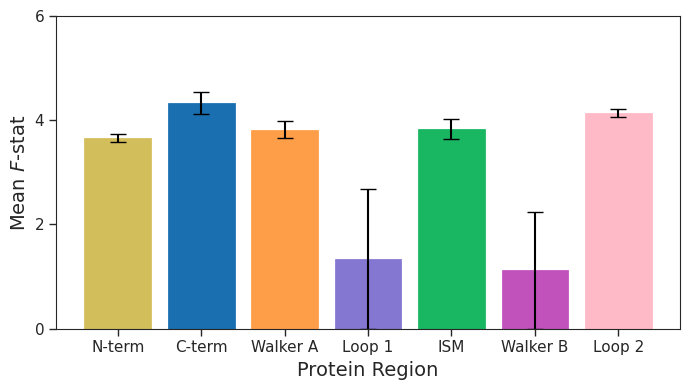

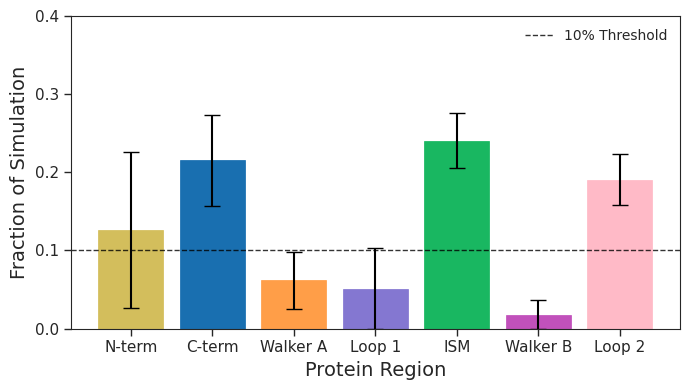

Clean ensemble plots saved to:
1. /content/drive/MyDrive/PATH/Ensemble_Active_F.png
2. /content/drive/MyDrive/PATH/Ensemble_Persistence.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

# --- 1. CONFIGURATION ---
csv_path = os.path.join(MAIN_OUTDIR, "ENSEMBLE_Granger_Summary_Table.csv")
REGION_ORDER = ["nt", "ct"]

# OPTION: Relabel region names for literature
# Change the values (right side) to match your preferred naming
LITERATURE_LABELS = {
    "n-terminal": "N-term",
    "c-terminal": "C-term"
}

BAR_COLORS = ["#CFB74A", "#005FA8", "#FF9434", "#7768CC", "#00B050", "#BB3EB4", "#FFB3C1"]

df_plot = pd.read_csv(csv_path)
df_plot = df_plot.set_index('region').reindex(REGION_ORDER).reset_index()

# Map the names to the literature-friendly versions
x_labels = [LITERATURE_LABELS.get(r, r) for r in REGION_ORDER]

sns.set_style("white")

# --- 2. PLOT 1: ENSEMBLE ACTIVE F-STAT ---
plt.figure(figsize=(7, 4))

plt.bar(df_plot['region'], df_plot['Mean_Active_F'],
        yerr=df_plot['SEM_Active_F'],
        capsize=6, color=BAR_COLORS, edgecolor=BAR_COLORS, linewidth=0.5, alpha=0.9)

plt.ylabel("Mean $F$-stat", fontsize=14)
plt.xlabel("Protein Region", fontsize=14)

# FIX: Axis Ticks
plt.xticks(range(len(REGION_ORDER)), x_labels, fontsize=11, fontweight='medium')
# Set y-ticks automatically based on data range (e.g., every 2 units)
max_f = df_plot['Mean_Active_F'].max() + df_plot['SEM_Active_F'].max()
plt.yticks(np.arange(0, max_f + 2, 2.0), fontsize=11)

# Style tick marks to be visible
plt.tick_params(axis='both', which='major', direction='out', length=5, width=1, bottom=True, left=True)
#sns.despine()

plt.tight_layout()
f_plot_path = os.path.join(MAIN_OUTDIR, "Ensemble_Active_F.png")
plt.savefig(f_plot_path, dpi=300)
plt.show()

# --- 3. PLOT 2: ENSEMBLE PERSISTENCE ---
plt.figure(figsize=(7, 4))

plt.bar(df_plot['region'], df_plot['Mean_Persistence'],
        yerr=df_plot['SEM_Persistence'],
        capsize=6, color=BAR_COLORS, edgecolor=BAR_COLORS, linewidth=0.5, alpha=0.9)

plt.axhline(0.10, color='black', linestyle='--', linewidth=1.0, alpha=0.8, label='10% Threshold')

plt.ylabel("Fraction of Simulation", fontsize=14)
plt.xlabel("Protein Region", fontsize=14)
plt.ylim(0, 0.4)

# FIX: Axis Ticks
plt.xticks(range(len(REGION_ORDER)), x_labels, fontsize=11, fontweight='medium')
plt.yticks(np.arange(0, 0.5, 0.1), fontsize=11)

plt.tick_params(axis='both', which='major', direction='out', length=5, width=1, bottom=True, left=True)
#sns.despine()

plt.legend(frameon=False, loc='upper right')
plt.tight_layout()
p_plot_path = os.path.join(MAIN_OUTDIR, "Ensemble_Persistence.png")
plt.savefig(p_plot_path, dpi=300)
plt.show()

print(f"Clean ensemble plots saved to:\n1. {f_plot_path}\n2. {p_plot_path}")